# OLAF ontology/KG alignment evaluation

This notebook evaluates whether the OLAF-generated KG is aligned with the OLAF-generated ontology, using ontology/KG alignment metrics complementary to the extraction P/R/F1 evaluator.

It checks:

- whether KG nodes are represented in the ontology;
- whether KG predicates are represented as ontology properties;
- whether full triples are ontology-aligned;
- whether used predicates have domain/range schema axioms;
- optional alignment between the generated OLAF ontology and the seed COInd4 ontology.

Before running this notebook, copy the patch files from `NeoOLAF_olaf_ontology_kg_alignment_patch.zip` into the repo root so that `src/neoolaf/evaluation/metrics/ontology_kg_alignment.py` exists.


In [1]:
from pathlib import Path
import sys
import json
import zipfile
import shutil

import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


In [2]:
def find_project_root(start: str | Path | None = None) -> Path:
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "src" / "neoolaf").exists():
            return p
    for p in candidates:
        if (p / "pyproject.toml").exists() and (p / "examples" / "XQualityMachine32").exists():
            return p
    raise RuntimeError("Could not find NeoOLAF project root. Run this notebook from inside the NeoOLAF repo.")

PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

EXAMPLE_ROOT = PROJECT_ROOT / "examples" / "XQualityMachine32"
RUNS_ROOT = EXAMPLE_ROOT / "runs"
MACHINE32_DIR = PROJECT_ROOT / "data" / "XQuality" / "Machine32"
SEED_ONTOLOGY_PATH = PROJECT_ROOT / "data" / "ontology" / "ContextOntology-COInd4.owl"

OUTPUT_DIR = RUNS_ROOT / "olaf_ontology_kg_alignment_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MACHINE32_DIR:", MACHINE32_DIR)
print("SEED_ONTOLOGY_PATH:", SEED_ONTOLOGY_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

if not MACHINE32_DIR.exists():
    raise FileNotFoundError(f"Machine32 directory not found: {MACHINE32_DIR}")


PROJECT_ROOT: C:\Users\henri\Documents\git\post-doc\NeoOLAF
MACHINE32_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32
SEED_ONTOLOGY_PATH: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\ontology\ContextOntology-COInd4.owl
OUTPUT_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_ontology_kg_alignment_eval


In [3]:
# Locate OLAF files. This supports either:
# 1) extracted files under data/XQuality/Machine32/**/output/..., or
# 2) OLAF_DEMO.zip copied into data/XQuality/Machine32.

AUTO_EXTRACT_ZIP = True

candidate_zips = sorted(MACHINE32_DIR.rglob("OLAF_DEMO.zip")) + sorted(MACHINE32_DIR.rglob("olaf_demo.zip"))
if AUTO_EXTRACT_ZIP and candidate_zips:
    zip_path = candidate_zips[0]
    extract_dir = MACHINE32_DIR / "OLAF_DEMO"
    expected = extract_dir / "output" / "llm_alarm_triplets.xlsx"
    if not expected.exists():
        print("Extracting:", zip_path, "->", extract_dir)
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)

def first_match(root: Path, patterns: list[str]) -> Path | None:
    for pattern in patterns:
        matches = sorted(root.rglob(pattern))
        if matches:
            return matches[0]
    return None

OLAF_XLSX = first_match(MACHINE32_DIR, ["llm_alarm_triplets.xlsx", "*triplet*.xlsx", "*triple*.xlsx"])
OLAF_TTL = first_match(MACHINE32_DIR, ["llm_alarm_ontology.ttl", "*ontology*.ttl"])
OLAF_SEED_FROM_ZIP = first_match(MACHINE32_DIR, ["ContextOntology-COInd4.owl"])

print("OLAF_XLSX:", OLAF_XLSX)
print("OLAF_TTL:", OLAF_TTL)
print("OLAF_SEED_FROM_ZIP:", OLAF_SEED_FROM_ZIP)

if OLAF_XLSX is None or not OLAF_XLSX.exists():
    raise FileNotFoundError("Could not find OLAF Excel triples file, e.g. llm_alarm_triplets.xlsx")
if OLAF_TTL is None or not OLAF_TTL.exists():
    raise FileNotFoundError("Could not find OLAF ontology TTL file, e.g. llm_alarm_ontology.ttl")

# Prefer repo seed ontology if available; otherwise use the one shipped in OLAF_DEMO.zip.
if not SEED_ONTOLOGY_PATH.exists() and OLAF_SEED_FROM_ZIP is not None:
    SEED_ONTOLOGY_PATH = OLAF_SEED_FROM_ZIP
print("Seed ontology used:", SEED_ONTOLOGY_PATH if SEED_ONTOLOGY_PATH.exists() else None)


OLAF_XLSX: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\output\llm_alarm_triplets.xlsx
OLAF_TTL: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\output\llm_alarm_ontology.ttl
OLAF_SEED_FROM_ZIP: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\data\ontologie\ContextOntology-COInd4.owl
Seed ontology used: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\ontology\ContextOntology-COInd4.owl


In [4]:
try:
    from neoolaf.evaluation.metrics.ontology_kg_alignment import (
        load_olaf_excel,
        olaf_excel_to_triples,
        write_neoolaf_kg,
        evaluate_kg_ontology_alignment,
        evaluate_ontology_seed_alignment,
    )
    print("Imported ontology/KG alignment metrics from NeoOLAF source.")
except Exception as exc:
    raise ImportError(
        "Could not import neoolaf.evaluation.metrics.ontology_kg_alignment. "
        "Please copy the patch files from NeoOLAF_olaf_ontology_kg_alignment_patch.zip "
        "into your repo root, then restart the kernel. Original error: " + repr(exc)
    )


Imported ontology/KG alignment metrics from NeoOLAF source.


In [5]:
# Load OLAF triples.
olaf_raw_df = load_olaf_excel(OLAF_XLSX)
olaf_triples, olaf_valid_df, olaf_skipped_df = olaf_excel_to_triples(olaf_raw_df)

NORMALIZED_KG_DIR = OUTPUT_DIR / "normalized_kg_export"
kg_path = write_neoolaf_kg(olaf_triples, NORMALIZED_KG_DIR)

olaf_raw_df.to_csv(OUTPUT_DIR / "olaf_raw_rows.csv", index=False)
olaf_valid_df.to_csv(OUTPUT_DIR / "olaf_valid_triples.csv", index=False)
olaf_skipped_df.to_csv(OUTPUT_DIR / "olaf_skipped_rows.csv", index=False)

print("Raw OLAF rows:", len(olaf_raw_df))
print("Valid KG triples:", len(olaf_triples))
print("Skipped rows:", len(olaf_skipped_df))
print("Normalized KG written to:", kg_path)

display(olaf_valid_df.head(30))
if len(olaf_skipped_df):
    print("Skipped row reasons:")
    display(olaf_skipped_df["skip_reason"].value_counts().to_frame("count"))


Raw OLAF rows: 82
Valid KG triples: 11
Skipped rows: 71
Normalized KG written to: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_ontology_kg_alignment_eval\normalized_kg_export\kg_inferred.json


,Source Node,Target Node,Relation,_sheet,subject,predicate,object,source_row
0,M3,error code,begin,Sheet,M3,begin,error code,71
1,error code,door,stop,Sheet,error code,stop,door,72
2,error code,stop at end of cycle,stop at,Sheet,error code,stop at,stop at end of cycle,73
3,spindle synchronization,spindle synchronization,stopped,Sheet,spindle synchronization,stopped,spindle synchronization,74
4,stop at end of cycle,Fanuc CNC series,stop,Sheet,stop at end of cycle,stop,Fanuc CNC series,75
5,stop at end of cycle,door,stop,Sheet,stop at end of cycle,stop,door,76
6,stop at end of cycle,stop at end of cycle,stops,Sheet,stop at end of cycle,stops,stop at end of cycle,77
7,tool,"AXIS <X, Z, Y>",enable to,Sheet,tool,enable to,"AXIS <X, Z, Y>",78
8,tool,input X4.3,enable to,Sheet,tool,enable to,input X4.3,79
9,tool,spindle synchronization,enable to,Sheet,tool,enable to,spindle synchronization,80


Skipped row reasons:


,count
skip_reason,
missing_source_or_target,71


In [6]:
# Main KG-to-ontology alignment evaluation.
# Thresholds are conservative; decrease them if you want more semantic/fuzzy matching.
NODE_FUZZY_THRESHOLD = 0.92
PREDICATE_FUZZY_THRESHOLD = 0.90

alignment_summary, alignment_details_df, ontology_inventory_df, ontology_index = evaluate_kg_ontology_alignment(
    olaf_triples,
    OLAF_TTL,
    node_fuzzy_threshold=NODE_FUZZY_THRESHOLD,
    predicate_fuzzy_threshold=PREDICATE_FUZZY_THRESHOLD,
)

summary_df = pd.DataFrame([alignment_summary])
summary_df.insert(0, "series", "olaf_demo")
summary_df.insert(1, "ontology_path", str(OLAF_TTL))
summary_df.insert(2, "kg_source_path", str(OLAF_XLSX))
summary_df.insert(3, "node_fuzzy_threshold", NODE_FUZZY_THRESHOLD)
summary_df.insert(4, "predicate_fuzzy_threshold", PREDICATE_FUZZY_THRESHOLD)

summary_path = OUTPUT_DIR / "olaf_kg_ontology_alignment_summary.csv"
details_path = OUTPUT_DIR / "olaf_kg_ontology_alignment_details.csv"
inventory_path = OUTPUT_DIR / "olaf_ontology_term_inventory.csv"

summary_df.to_csv(summary_path, index=False)
alignment_details_df.to_csv(details_path, index=False)
ontology_inventory_df.to_csv(inventory_path, index=False)

print("Saved:", summary_path)
print("Saved:", details_path)
print("Saved:", inventory_path)

main_cols = [
    "kg_triple_count",
    "kg_unique_node_count",
    "kg_unique_predicate_count",
    "kg_unique_node_alignment_rate",
    "kg_unique_predicate_alignment_rate",
    "kg_full_triple_alignment_rate",
    "kg_predicate_domain_range_axiom_rate",
    "kg_unique_predicate_domain_range_axiom_rate",
    "kg_alignment_hmean",
    "kg_schema_alignment_hmean",
    "kg_ontology_alignment_score",
    "ontology_class_count",
    "ontology_property_count",
    "ontology_properties_with_domain_range_count",
    "ontology_property_domain_range_rate",
]

display(summary_df[[c for c in main_cols if c in summary_df.columns]].T.rename(columns={0: "value"}))


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_ontology_kg_alignment_eval\olaf_kg_ontology_alignment_summary.csv
Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_ontology_kg_alignment_eval\olaf_kg_ontology_alignment_details.csv
Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_ontology_kg_alignment_eval\olaf_ontology_term_inventory.csv


,value
kg_triple_count,11.0
kg_unique_node_count,9.0
kg_unique_predicate_count,7.0
kg_unique_node_alignment_rate,1.0
kg_unique_predicate_alignment_rate,1.0
kg_full_triple_alignment_rate,1.0
kg_predicate_domain_range_axiom_rate,0.0
kg_unique_predicate_domain_range_axiom_rate,0.0
kg_alignment_hmean,1.0
kg_schema_alignment_hmean,0.0


In [7]:
# Detailed alignment table for the valid OLAF triples.
detail_cols = [
    "subject", "predicate", "object",
    "subject_aligned", "subject_match_kind", "subject_canonical_label",
    "predicate_aligned", "predicate_match_kind", "predicate_canonical_label",
    "object_aligned", "object_match_kind", "object_canonical_label",
    "fully_aligned",
    "predicate_has_domain", "predicate_has_range", "predicate_has_domain_range",
    "domain_consistent_when_applicable", "range_consistent_when_applicable",
]
display(alignment_details_df[[c for c in detail_cols if c in alignment_details_df.columns]])


,subject,predicate,object,subject_aligned,subject_match_kind,subject_canonical_label,predicate_aligned,predicate_match_kind,predicate_canonical_label,object_aligned,object_match_kind,object_canonical_label,fully_aligned,predicate_has_domain,predicate_has_range,predicate_has_domain_range,domain_consistent_when_applicable,range_consistent_when_applicable
0,M3,begin,error code,True,exact,M3,True,exact,start,True,exact,ErrorCode,True,False,False,False,None,None
1,error code,stop,door,True,exact,ErrorCode,True,exact,stop,True,exact,Door,True,False,False,False,None,None
2,error code,stop at,stop at end of cycle,True,exact,ErrorCode,True,exact,stop,True,exact,StopAtEndOfCycle,True,False,False,False,None,None
3,spindle synchronization,stopped,spindle synchronization,True,exact,SpindleSynchronization,True,exact,stop,True,exact,SpindleSynchronization,True,False,False,False,None,None
4,stop at end of cycle,stop,Fanuc CNC series,True,exact,StopAtEndOfCycle,True,exact,stop,True,exact,FanucCncSeries,True,False,False,False,None,None
5,stop at end of cycle,stop,door,True,exact,StopAtEndOfCycle,True,exact,stop,True,exact,Door,True,False,False,False,None,None
6,stop at end of cycle,stops,stop at end of cycle,True,exact,StopAtEndOfCycle,True,exact,stops,True,exact,StopAtEndOfCycle,True,False,False,False,None,None
7,tool,enable to,"AXIS <X, Z, Y>",True,exact,Tool,True,exact,enableTo,True,exact,Axis%3Cx%2CZ%2CY%3E,True,False,False,False,None,None
8,tool,enable to,input X4.3,True,exact,Tool,True,exact,enableTo,True,exact,InputX4.3,True,False,False,False,None,None
9,tool,enable to,spindle synchronization,True,exact,Tool,True,exact,enableTo,True,exact,SpindleSynchronization,True,False,False,False,None,None


In [8]:
# Optional: align generated OLAF ontology terms to the seed COInd4 ontology.
seed_summary_df = pd.DataFrame()
seed_alignment_df = pd.DataFrame()

if SEED_ONTOLOGY_PATH is not None and Path(SEED_ONTOLOGY_PATH).exists():
    seed_summary, seed_alignment_df = evaluate_ontology_seed_alignment(OLAF_TTL, SEED_ONTOLOGY_PATH)
    seed_summary_df = pd.DataFrame([seed_summary])
    seed_summary_df.insert(0, "series", "olaf_generated_ontology_vs_seed")
    seed_summary_df.insert(1, "generated_ontology_path", str(OLAF_TTL))
    seed_summary_df.insert(2, "seed_ontology_path", str(SEED_ONTOLOGY_PATH))

    seed_summary_path = OUTPUT_DIR / "olaf_ontology_seed_alignment_summary.csv"
    seed_details_path = OUTPUT_DIR / "olaf_ontology_seed_alignment_details.csv"
    seed_summary_df.to_csv(seed_summary_path, index=False)
    seed_alignment_df.to_csv(seed_details_path, index=False)

    print("Saved:", seed_summary_path)
    print("Saved:", seed_details_path)
    display(seed_summary_df.T.rename(columns={0: "value"}))
    display(seed_alignment_df.head(50))
else:
    print("No seed ontology found; skipping generated ontology vs seed alignment.")


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_ontology_kg_alignment_eval\olaf_ontology_seed_alignment_summary.csv
Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_ontology_kg_alignment_eval\olaf_ontology_seed_alignment_details.csv


,value
series,olaf_generated_ontology_vs_seed
generated_ontology_path,C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\output\llm_alarm_ontology.ttl
seed_ontology_path,C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\ontology\ContextOntology-COInd4.owl
generated_alignable_term_count,136
generated_seed_aligned_term_count,101
generated_seed_alignment_rate,0.742647
seed_alignment_class_count,59
seed_alignment_class_aligned_count,50
seed_alignment_class_rate,0.847458
seed_alignment_object_property_count,77


,generated_uri,generated_label,generated_term_type,aligned_to_seed,seed_match_kind,seed_match_score,seed_uri,seed_canonical_label
0,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#intervalMeets,intervalMeets,object_property,True,exact,1.000000,http://www.w3.org/2006/time#intervalMeets,intervalMeets
1,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#enableTo,enableTo,object_property,False,none,0.526316,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#definedOn,defined on
2,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#intervalIn,intervalIn,object_property,True,exact,1.000000,http://www.w3.org/2006/time#intervalIn,intervalIn
3,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#cause,cause,object_property,False,none,0.714286,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#hasCause,has cause
4,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#isInSituation,isInSituation,object_property,True,exact,1.000000,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#isInSituation,isInSituation
5,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#Manager,Manager,class,True,exact,1.000000,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#Manager,Manager
6,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#ObservableProperty,ObservableProperty,class,True,exact,1.000000,http://www.w3.org/ns/sosa/ObservableProperty,ObservableProperty
7,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#SituationS6,SituationS6,class,True,exact,1.000000,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#Situation-S6,Situation-S6
8,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#stop,stop,object_property,False,none,0.705882,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#hasTime,has time
9,http://semanticweb.org/STEaMINg/ContextOntology-COInd4#Geometry,Geometry,class,True,exact,1.000000,http://www.opengis.net/ont/geosparql#Geometry,Geometry


In [10]:
# Compact interpretation helper.
row = summary_df.iloc[0]
print("KG-to-ontology alignment interpretation")
print("---------------------------------------")
print(f"Valid KG triples: {int(row['kg_triple_count'])}")
print(f"Unique KG nodes aligned to ontology: {row['kg_unique_node_alignment_rate']:.3f}")
print(f"Unique KG predicates aligned to ontology: {row['kg_unique_predicate_alignment_rate']:.3f}")
print(f"Full triple alignment rate: {row['kg_full_triple_alignment_rate']:.3f}")
print(f"Predicate domain+range axiom coverage: {row['kg_unique_predicate_domain_range_axiom_rate']:.3f}")
print(f"KG lexical alignment H-mean: {row['kg_alignment_hmean']:.3f}")
print(f"KG schema alignment H-mean: {row['kg_schema_alignment_hmean']:.3f}")
print(f"Overall KG/ontology alignment score: {row['kg_ontology_alignment_score']:.3f}")

print("Important reading:")
print("- High node/predicate/full-triple alignment means the KG vocabulary is represented in the generated ontology.")
print("- Low domain/range coverage means the ontology is mostly a vocabulary/list of terms, not a constraining schema.")
print("- If KG lexical alignment is high but schema alignment is low, say: OLAF aligns its KG to its ontology labels, but the ontology does not provide enough formal schema constraints.")


KG-to-ontology alignment interpretation
---------------------------------------
Valid KG triples: 11
Unique KG nodes aligned to ontology: 1.000
Unique KG predicates aligned to ontology: 1.000
Full triple alignment rate: 1.000
Predicate domain+range axiom coverage: 0.000
KG lexical alignment H-mean: 1.000
KG schema alignment H-mean: 0.000
Overall KG/ontology alignment score: 0.000
Important reading:
- High node/predicate/full-triple alignment means the KG vocabulary is represented in the generated ontology.
- Low domain/range coverage means the ontology is mostly a vocabulary/list of terms, not a constraining schema.
- If KG lexical alignment is high but schema alignment is low, say: OLAF aligns its KG to its ontology labels, but the ontology does not provide enough formal schema constraints.


C:\Users\henri\AppData\Local\Temp\ipykernel_24692\335039925.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["metric"], rotation=30, ha="right")


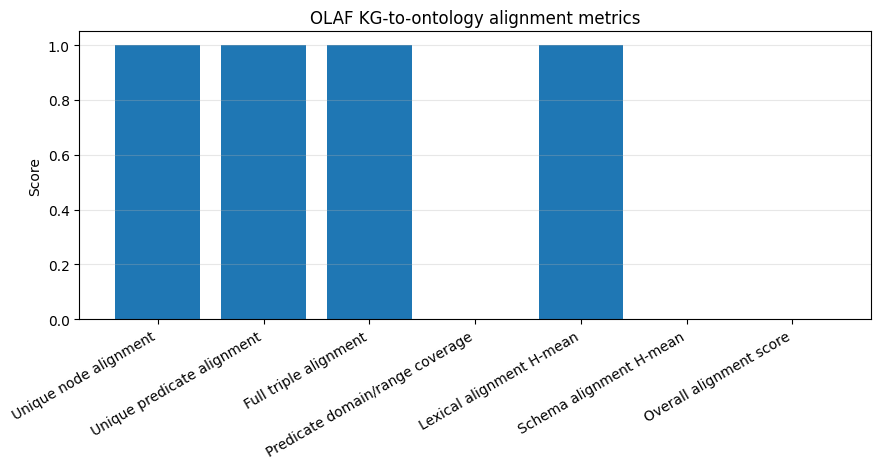

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_ontology_kg_alignment_eval\olaf_kg_ontology_alignment_metrics.png


C:\Users\henri\AppData\Local\Temp\ipykernel_24692\335039925.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(seed_plot_df["metric"], rotation=25, ha="right")


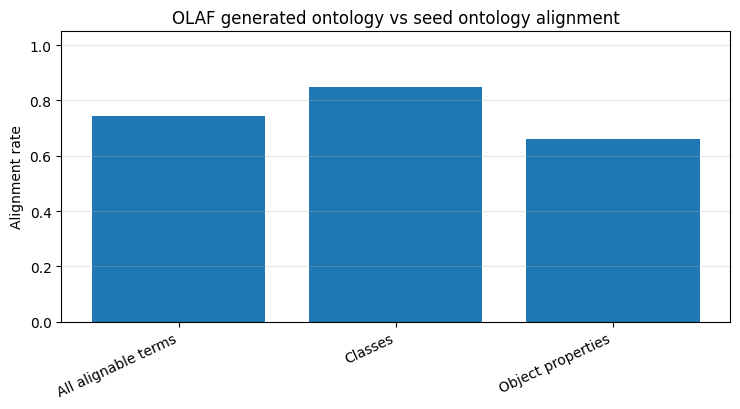

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_ontology_kg_alignment_eval\olaf_ontology_seed_alignment_metrics.png


In [11]:
import matplotlib.pyplot as plt

plot_metrics = [
    ("kg_unique_node_alignment_rate", "Unique node alignment"),
    ("kg_unique_predicate_alignment_rate", "Unique predicate alignment"),
    ("kg_full_triple_alignment_rate", "Full triple alignment"),
    ("kg_unique_predicate_domain_range_axiom_rate", "Predicate domain/range coverage"),
    ("kg_alignment_hmean", "Lexical alignment H-mean"),
    ("kg_schema_alignment_hmean", "Schema alignment H-mean"),
    ("kg_ontology_alignment_score", "Overall alignment score"),
]

plot_df = pd.DataFrame([
    {"metric": label, "value": float(summary_df.iloc[0][col])}
    for col, label in plot_metrics
    if col in summary_df.columns
])

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(plot_df["metric"], plot_df["value"])
ax.set_title("OLAF KG-to-ontology alignment metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(plot_df["metric"], rotation=30, ha="right")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plot_path = OUTPUT_DIR / "olaf_kg_ontology_alignment_metrics.png"
fig.savefig(plot_path, dpi=180)
plt.show()
print("Saved:", plot_path)

if not seed_summary_df.empty:
    seed_plot_metrics = [
        ("generated_seed_alignment_rate", "All alignable terms"),
        ("seed_alignment_class_rate", "Classes"),
        ("seed_alignment_object_property_rate", "Object properties"),
    ]
    seed_plot_df = pd.DataFrame([
        {"metric": label, "value": float(seed_summary_df.iloc[0][col])}
        for col, label in seed_plot_metrics
        if col in seed_summary_df.columns
    ])
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.bar(seed_plot_df["metric"], seed_plot_df["value"])
    ax.set_title("OLAF generated ontology vs seed ontology alignment")
    ax.set_ylabel("Alignment rate")
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(seed_plot_df["metric"], rotation=25, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    seed_plot_path = OUTPUT_DIR / "olaf_ontology_seed_alignment_metrics.png"
    fig.savefig(seed_plot_path, dpi=180)
    plt.show()
    print("Saved:", seed_plot_path)


## Suggested wording

Use wording like this if the OLAF metrics show high lexical alignment but low schema alignment:

> The OLAF KG is lexically aligned with its generated ontology, since KG nodes and predicates are represented as ontology terms. However, the generated ontology provides limited formal schema support: used predicates have little or no domain/range coverage. Therefore, the ontology acts mainly as a vocabulary layer rather than as a constraining schema for validating KG triples.

This is different from extraction F1. It evaluates whether the generated KG is structurally connected to the generated ontology.
